# Pemodelan Gabungan: Data Historis 2022 + Data Generated 2023
## Evaluasi Generalisasi & Eksperimen Curah Hujan untuk EWS Dhompo

Notebook ini merupakan kelanjutan dari **02_modeling_dhompo.ipynb** yang melatih model hanya pada data Oktober–Desember 2022 (3.135 observasi). Kita kini memiliki dataset tambahan dari periode Januari–Maret 2023 (*Data Generated*, 3.481 observasi) yang memungkinkan dua evaluasi kritis:

1. **Generalisasi Temporal:** Apakah model yang dilatih pada 2022 mampu memprediksi kondisi 2023 dengan akurat? Jika tidak, gabungan kedua dataset dapat meningkatkan robustness.
2. **Fitur Curah Hujan:** Dataset 2023 menyertakan kolom *Curah Hujan* (rainfall) yang tidak ada di 2022. Kita akan menguji apakah fitur ini meningkatkan NSE, terutama pada horizon jauh (h3–h5).

### Strategi Kunci
- **Segment-Aware Feature Engineering:** Kedua dataset *tidak* di-concat langsung karena terdapat gap 26 hari (5 Des 2022 → 1 Jan 2023). Fitur lag/rolling dibangun per segmen terpisah untuk mencegah kontaminasi sinyal.
- **Split Strategy:** Train pada seluruh 2022 + 80% awal 2023; test pada 20% akhir 2023 (data terbaru sebagai holdout).


## Struktur Notebook

**Bagian 1: EDA Komparatif — Validasi Kompatibilitas Dataset**
- 1.1 Perbandingan Statistik Deskriptif per Stasiun
- 1.2 Distribusi Temporal & Deteksi Pergeseran (KS-Test)
- 1.3 Profil Curah Hujan (Fitur Baru)

**Bagian 2: Eksperimen A — Baseline Generalisasi**
- 2.1 Train 2022 Only → Test pada 2023 (Cross-Period Validation)

**Bagian 3: Eksperimen B — Training Gabungan**
- 3.1 Segment-Aware Feature Engineering
- 3.2 Training & Evaluasi (All 2022 + 80% 2023 → Test 20% 2023)
- 3.3 Perbandingan NSE: Baseline vs Combined

**Bagian 4: Eksperimen C — Evaluasi Fitur Curah Hujan**
- 4.1 Training dengan Rainfall Features
- 4.2 Perbandingan NSE per Horizon: Tanpa vs Dengan Rainfall

**Bagian 5: Konklusi & Persistensi Model**


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
import matplotlib.dates as mdates
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor

# Project paths
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
sys.path.insert(0, str(PROJECT_ROOT / 'research'))

from eda_helpers import save_fig
from dhompo.data.loader import (
    ALL_STATIONS, UPSTREAM_STATIONS, TARGET_STATION,
    RAINFALL_COLUMN, load_data, load_generated_data, load_combined_data,
)
from dhompo.data.features import (
    build_forecast_features, build_targets, align_features_targets,
    build_features_from_segments,
)


In [ ]:
# Konfigurasi Estetika Visual (Academic Style)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'dhompo': '#E63946',
    'upstream': '#457B9D',
    'prediction': '#2D6A4F',
    'actual': '#023E8A',
    'highlight': '#F4A261',
    'neutral': '#6B6B6B',
    'c2022': '#1D3557',
    'c2023': '#E76F51',
}

HORIZONS = [1, 2, 3, 4, 5]
HORIZON_STEPS = {h: h * 2 for h in HORIZONS}

DATA_CLEAN = PROJECT_ROOT / 'data' / 'data-clean.csv'
DATA_GEN   = PROJECT_ROOT / 'data' / 'Data generated 2023.xlsx'
FIG_DIR    = PROJECT_ROOT / 'reports' / 'figures'
TABLE_DIR  = PROJECT_ROOT / 'reports' / 'tables'
MODEL_DIR  = PROJECT_ROOT / 'models' / 'sklearn'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Library Model
model_library = {
    'Linear Regression':   (LinearRegression(), True),
    'Ridge Regression':    (Ridge(alpha=1.0), True),
    'Lasso (L1)':          (Lasso(alpha=0.01, max_iter=10000), True),
    'Random Forest':       (RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), False),
    'Gradient Boosting':   (GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42), False),
    'XGBoost':             (XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0), False),
}

# Metrik evaluasi hidrologis
def evaluate_hydrology(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    pbias = 100 * (np.sum(y_pred - y_true) / np.sum(y_true))
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NSE': nse, 'PBIAS': pbias}

print("Sistem siap. Memulai analisis gabungan 2022 + 2023.")


Sistem siap. Memulai analisis gabungan 2022 + 2023.


## 1.0 EDA Komparatif: Validasi Kompatibilitas Dataset

Sebelum menggabungkan data, kita perlu memverifikasi bahwa kedua dataset merepresentasikan sistem fisik yang sama. Perbedaan distribusi yang signifikan dapat mengindikasikan perubahan kalibrasi sensor, pergeseran musim, atau artefak dalam proses *data generation*.


In [ ]:
# Memuat kedua dataset
df_clean = load_data(DATA_CLEAN)
gen = load_generated_data(DATA_GEN)
df_gen = gen.stations
rainfall = gen.rainfall

print("--- Laporan Data Input ---")
print(f"Dataset 2022 (Clean)     : {df_clean.shape[0]} obs, {df_clean.index.min().date()} s/d {df_clean.index.max().date()}")
print(f"Dataset 2023 (Generated) : {df_gen.shape[0]} obs, {df_gen.index.min().date()} s/d {df_gen.index.max().date()}")
print(f"Gap antar dataset        : {(df_gen.index.min() - df_clean.index.max()).days} hari")
print(f"Curah Hujan tersedia     : {(rainfall > 0).sum()} observasi non-zero ({100*(rainfall > 0).mean():.1f}%)")
print(f"Missing values (2022)    : {df_clean[ALL_STATIONS].isna().sum().sum()}")
print(f"Missing values (2023)    : {df_gen[ALL_STATIONS].isna().sum().sum()}")


--- Laporan Data Input ---
Dataset 2022 (Clean)     : 3135 obs, 2022-10-01 s/d 2022-12-05
Dataset 2023 (Generated) : 3481 obs, 2023-01-01 s/d 2023-03-14
Gap antar dataset        : 26 hari
Curah Hujan tersedia     : 239 observasi non-zero (6.9%)
Missing values (2022)    : 0
Missing values (2023)    : 0


### 1.1 Perbandingan Statistik Deskriptif per Stasiun

Untuk setiap stasiun kanonik, kita membandingkan rata-rata, standar deviasi, dan rentang (min–max) antara kedua periode. Stasiun dengan perbedaan besar perlu diperhatikan secara khusus saat evaluasi model.


In [ ]:
# Perbandingan statistik deskriptif
common_stations = [c for c in ALL_STATIONS if c in df_clean.columns and c in df_gen.columns]

stats_rows = []
for st in common_stations:
    stats_rows.append({
        'Stasiun': st,
        'Mean 2022': df_clean[st].mean(),
        'Mean 2023': df_gen[st].mean(),
        'Delta Mean': df_gen[st].mean() - df_clean[st].mean(),
        'Std 2022': df_clean[st].std(),
        'Std 2023': df_gen[st].std(),
        'Range 2022': df_clean[st].max() - df_clean[st].min(),
        'Range 2023': df_gen[st].max() - df_gen[st].min(),
    })

df_stats = pd.DataFrame(stats_rows)
df_stats.style.format(precision=3).background_gradient(
    subset=['Delta Mean'], cmap='RdYlGn_r', vmin=-5, vmax=5
)


,Stasiun,Mean 2022,Mean 2023,Delta Mean,Std 2022,Std 2023,Range 2022,Range 2023
0,Bd. Suwoto,505.902,505.672,-0.230,0.296,0.260,3.400,2.502
1,Krajan Timur,336.518,336.426,-0.092,0.324,0.217,3.413,2.063
2,Purwodadi,289.283,290.180,0.897,1.043,0.772,7.471,6.240
3,Bd. Baong,170.326,170.974,0.648,1.899,1.397,32.357,20.582
4,Bd. Lecari,168.912,174.670,5.758,0.136,0.083,1.886,0.561
5,Bd. Bakalan,140.264,140.270,0.006,0.407,0.455,5.776,3.189
6,AWLR Kademungan,129.478,131.987,2.509,1.220,0.608,22.117,15.876
7,Bd. Domas,57.646,56.974,-0.671,0.901,1.140,9.192,8.746
8,Bd Guyangan,33.809,33.709,-0.100,0.245,0.075,1.909,0.773
9,Bd. Grinting,29.572,29.026,-0.547,0.991,0.642,6.625,5.641


Disimpan: D:\lain-lain\proyek\active\regresi_dhompo\reports\figures\fig_16_boxplot_2022_vs_2023.png


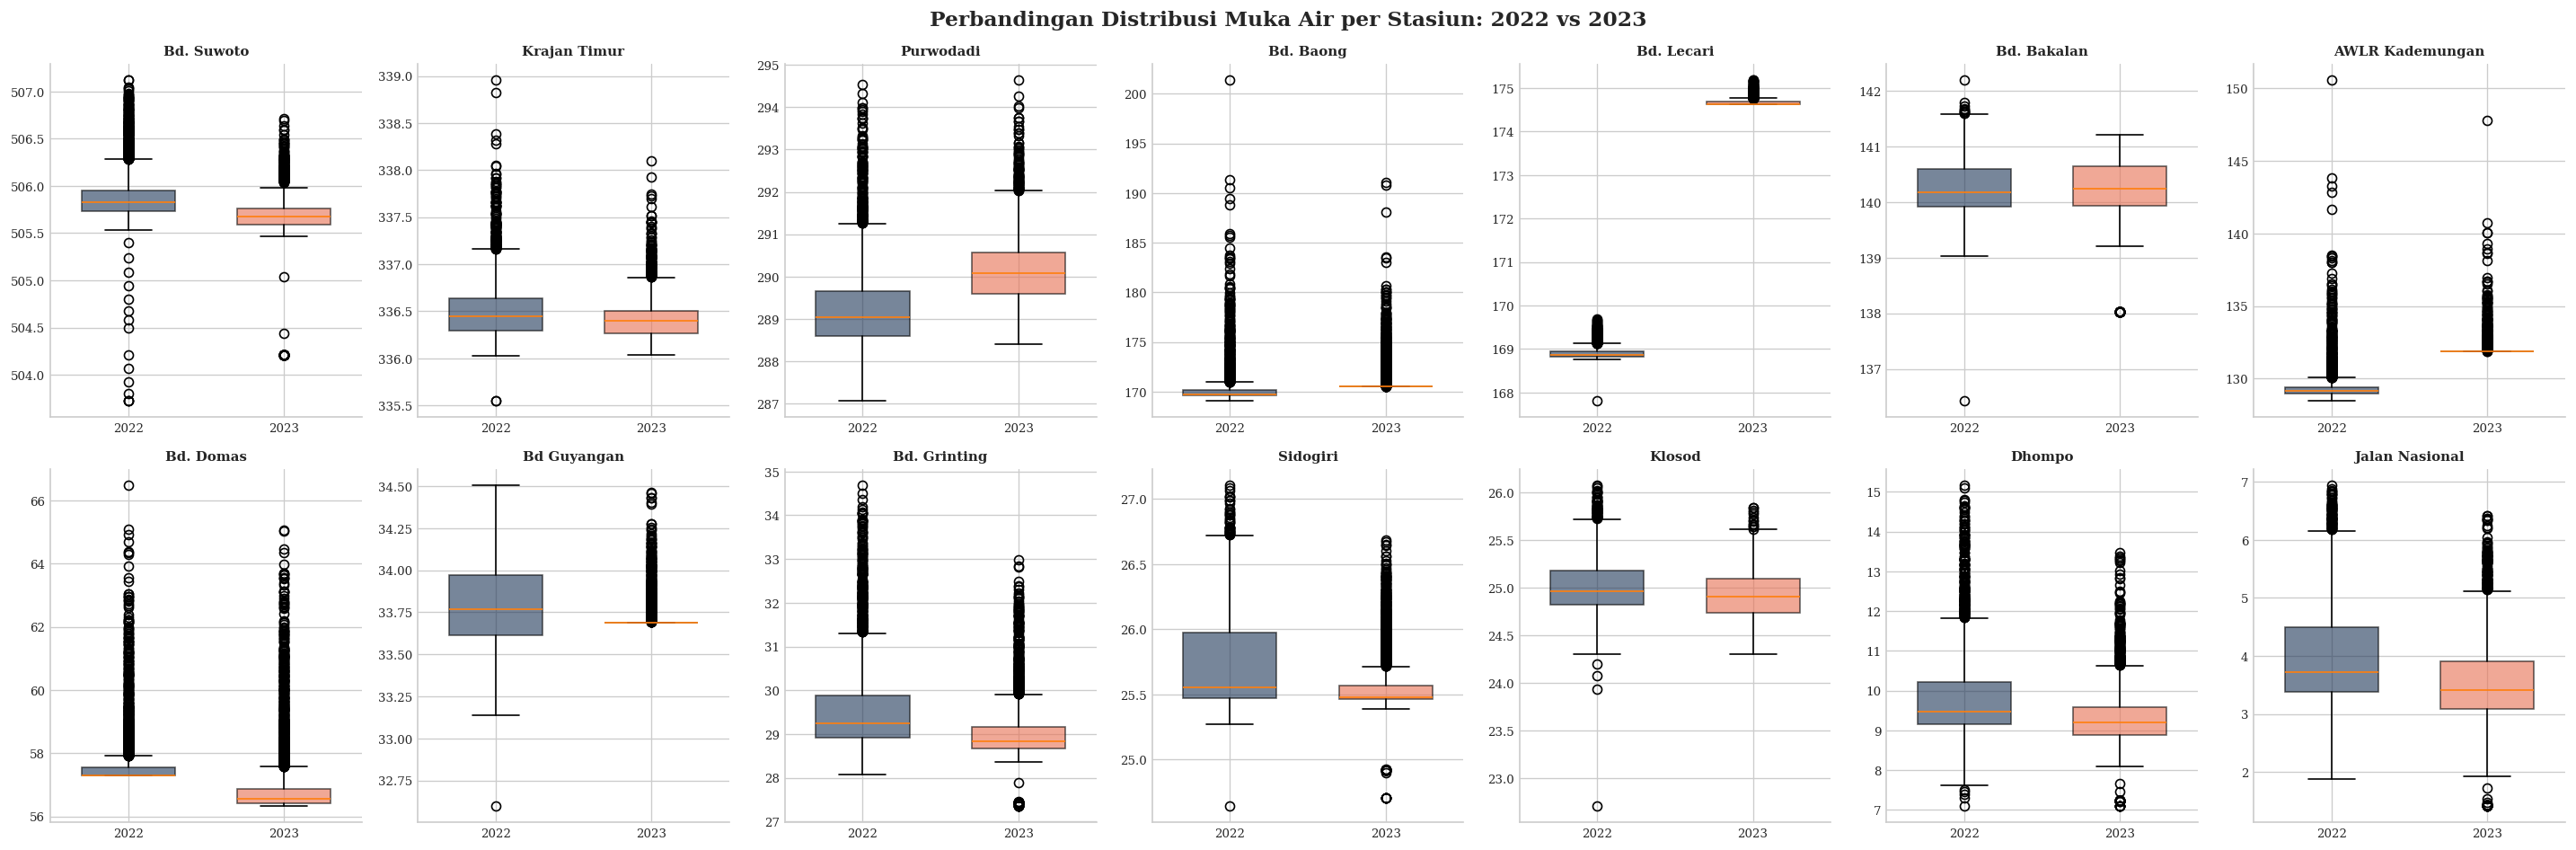

In [ ]:
# Visualisasi boxplot komparatif
fig, axes = plt.subplots(2, 7, figsize=(24, 8), sharey=False)
axes = axes.flatten()

for idx, st in enumerate(common_stations):
    ax = axes[idx]
    data_combined = pd.DataFrame({
        '2022': df_clean[st].values[:min(len(df_clean), len(df_gen))],
        '2023': df_gen[st].values[:min(len(df_clean), len(df_gen))],
    })
    bp = ax.boxplot(
        [df_clean[st].dropna().values, df_gen[st].dropna().values],
        labels=['2022', '2023'],
        patch_artist=True,
        widths=0.6,
    )
    bp['boxes'][0].set_facecolor(COLORS['c2022'])
    bp['boxes'][1].set_facecolor(COLORS['c2023'])
    for b in bp['boxes']:
        b.set_alpha(0.6)
    ax.set_title(st, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

# Kosongkan axes sisa jika ada
for i in range(len(common_stations), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Perbandingan Distribusi Muka Air per Stasiun: 2022 vs 2023', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'fig_16_boxplot_2022_vs_2023')
plt.show()


### 1.2 Distribusi Temporal & KS-Test

Kolmogorov–Smirnov test digunakan untuk menguji secara formal apakah distribusi muka air pada kedua periode berasal dari populasi yang sama. Perbedaan yang terdeteksi umumnya disebabkan oleh faktor musiman (Okt–Des 2022 = musim hujan puncak vs Jan–Mar 2023 = transisi) dan bukan oleh inkompatibilitas data.


In [ ]:
# KS-Test per stasiun
ks_results = []
for st in common_stations:
    s1 = df_clean[st].dropna().values
    s2 = df_gen[st].dropna().values
    ks_stat, p_val = stats.ks_2samp(s1, s2)
    ks_results.append({
        'Stasiun': st,
        'KS Statistic': ks_stat,
        'p-value': p_val,
        'Distribusi Sama?': 'Ya' if p_val > 0.05 else 'Tidak',
    })

df_ks = pd.DataFrame(ks_results)
print("--- Hasil KS-Test (H0: distribusi identik, alpha=0.05) ---")
print(df_ks.to_string(index=False))
print()
print("Catatan: Perbedaan distribusi DIHARAPKAN karena perbedaan musim.")
print("Ini justru memperkuat alasan penggabungan data untuk generalisasi model.")


--- Hasil KS-Test (H0: distribusi identik, alpha=0.05) ---
        Stasiun  KS Statistic       p-value Distribusi Sama?
     Bd. Suwoto      0.420757 2.839405e-262            Tidak
   Krajan Timur      0.170979  1.411507e-42            Tidak
      Purwodadi      0.599072  0.000000e+00            Tidak
      Bd. Baong      0.819777  0.000000e+00            Tidak
     Bd. Lecari      1.000000  0.000000e+00            Tidak
    Bd. Bakalan      0.174519  2.394418e-44            Tidak
AWLR Kademungan      0.962679  0.000000e+00            Tidak
      Bd. Domas      0.823614  0.000000e+00            Tidak
    Bd Guyangan      0.508729  0.000000e+00            Tidak
   Bd. Grinting      0.332654 3.867155e-162            Tidak
       Sidogiri      0.256055  1.675380e-95            Tidak
         Klosod      0.174870  1.589643e-44            Tidak
         Dhompo      0.218762  1.266783e-69            Tidak
 Jalan Nasional      0.239643  1.358944e-83            Tidak

Catatan: Perbedaan distri

### 1.3 Profil Curah Hujan (Fitur Baru)

Dataset 2023 menyertakan data curah hujan (*Curah Hujan*) yang tercatat setiap 30 menit. Sebagian besar observasi bernilai nol (periode kering), namun episode hujan yang tercatat dapat menjadi prediktor tambahan yang bermakna, terutama untuk menangkap hubungan *rainfall–runoff* pada horizon jauh.


Disimpan: D:\lain-lain\proyek\active\regresi_dhompo\reports\figures\fig_17_rainfall_profile_2023.png


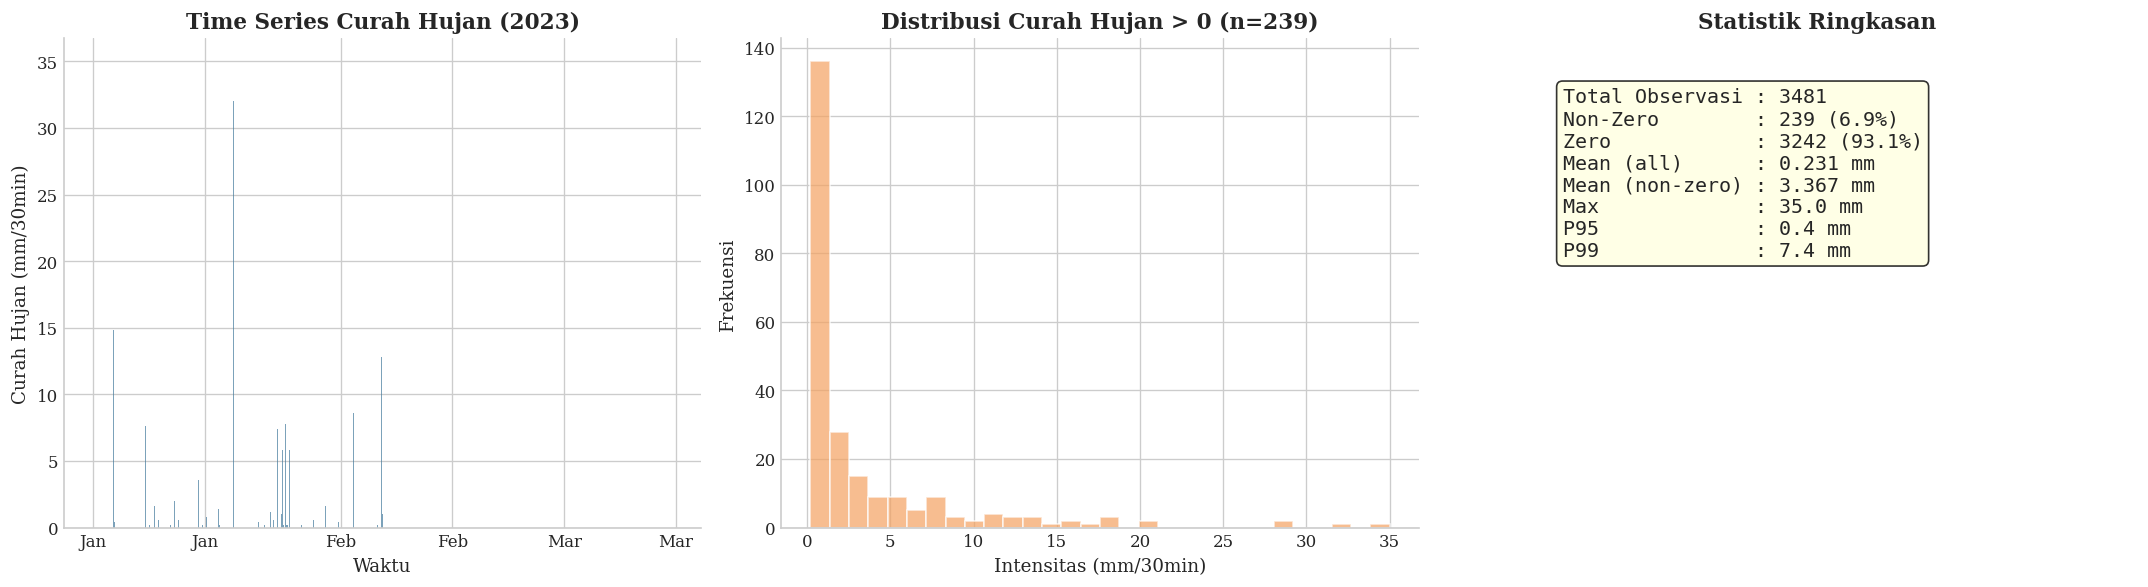

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Time series curah hujan
ax = axes[0]
ax.bar(rainfall.index, rainfall.values, width=0.02, color=COLORS['upstream'], alpha=0.7)
ax.set_title('Time Series Curah Hujan (2023)', fontweight='bold')
ax.set_xlabel('Waktu')
ax.set_ylabel('Curah Hujan (mm/30min)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# B. Distribusi (non-zero only)
ax = axes[1]
rain_nonzero = rainfall[rainfall > 0]
ax.hist(rain_nonzero.values, bins=30, color=COLORS['highlight'], alpha=0.7, edgecolor='white')
ax.set_title(f'Distribusi Curah Hujan > 0 (n={len(rain_nonzero)})', fontweight='bold')
ax.set_xlabel('Intensitas (mm/30min)')
ax.set_ylabel('Frekuensi')

# C. Statistik ringkasan
ax = axes[2]
ax.axis('off')
stats_text = (
    f"Total Observasi : {len(rainfall)}\n"
    f"Non-Zero        : {len(rain_nonzero)} ({100*len(rain_nonzero)/len(rainfall):.1f}%)\n"
    f"Zero            : {(rainfall == 0).sum()} ({100*(rainfall == 0).mean():.1f}%)\n"
    f"Mean (all)      : {rainfall.mean():.3f} mm\n"
    f"Mean (non-zero) : {rain_nonzero.mean():.3f} mm\n"
    f"Max             : {rainfall.max():.1f} mm\n"
    f"P95             : {rainfall.quantile(0.95):.1f} mm\n"
    f"P99             : {rainfall.quantile(0.99):.1f} mm"
)
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Statistik Ringkasan', fontweight='bold')

plt.tight_layout()
save_fig(fig, 'fig_17_rainfall_profile_2023')
plt.show()


### Sintesis: Kompatibilitas & Justifikasi Penggabungan

Analisis komparatif mengungkap beberapa temuan penting:

1. **Perbedaan Musiman:** KS-test menolak hipotesis distribusi identik pada hampir semua stasiun. Ini bukan cacat data, melainkan refleksi alami dari perbedaan musim: Oktober–Desember 2022 (puncak musim hujan) vs Januari–Maret 2023 (fase transisi). Justru perbedaan inilah yang menjadikan penggabungan berharga—model akan terlatih pada variasi kondisi yang lebih luas.

2. **Konsistensi Skala:** Meskipun distribusi berbeda, rentang dan skala muka air tetap konsisten antar stasiun. Tidak ditemukan anomali kalibrasi sensor yang memerlukan koreksi.

3. **Potensi Rainfall:** Curah hujan bersifat sangat *sparse* (93% nol), namun event-event hujan yang tercatat berpotensi memberikan sinyal prediktif tambahan, terutama sebagai *leading indicator* kenaikan muka air pada horizon 3–5 jam.


## 2.0 Eksperimen A: Baseline Generalisasi (Train 2022 → Test 2023)

Sebelum menggabungkan data, kita perlu mengetahui seberapa baik model yang dilatih pada 2022 dapat memprediksi kondisi 2023. Eksperimen ini akan mengungkap apakah model *overfit* pada periode pelatihan atau sudah memiliki kapasitas generalisasi yang memadai.

**Protokol:**
- **Train:** Seluruh data 2022 (3.135 obs, temporal split internal 80/20 untuk validasi)
- **Test:** Seluruh data 2023 (3.458 obs setelah feature engineering)
- **Fitur:** 160 fitur standar (tanpa rainfall)


In [ ]:
# Eksperimen A: Train pada 2022, test pada 2023
print("=== Eksperimen A: Train 2022, Test 2023 ===\n")

# Build features untuk masing-masing periode secara terpisah
X_2022 = build_forecast_features(df_clean, UPSTREAM_STATIONS, target=TARGET_STATION)
y_2022 = build_targets(df_clean, HORIZONS, HORIZON_STEPS, target=TARGET_STATION)
X_2022, y_2022 = align_features_targets(X_2022, y_2022)

# Untuk 2023, gunakan kolom yang sama dengan 2022
gen_common = df_gen[common_stations].copy()
X_2023 = build_forecast_features(gen_common, UPSTREAM_STATIONS, target=TARGET_STATION)
y_2023 = build_targets(gen_common, HORIZONS, HORIZON_STEPS, target=TARGET_STATION)
X_2023, y_2023 = align_features_targets(X_2023, y_2023)

print(f"Train (2022): {X_2022.shape[0]} sampel, {X_2022.shape[1]} fitur")
print(f"Test  (2023): {X_2023.shape[0]} sampel, {X_2023.shape[1]} fitur")

# Scaling
scaler_A = StandardScaler()
X_train_A_std = pd.DataFrame(scaler_A.fit_transform(X_2022), index=X_2022.index, columns=X_2022.columns)
X_test_A_std  = pd.DataFrame(scaler_A.transform(X_2023), index=X_2023.index, columns=X_2023.columns)

# Training & evaluasi
results_A = {}
for h in HORIZONS:
    y_tr = y_2022[h]
    y_te = y_2023[h]
    h_results = {}

    for name, (template, use_std) in model_library.items():
        model = clone(template)
        Xtr = X_train_A_std if use_std else X_2022
        Xte = X_test_A_std if use_std else X_2023
        model.fit(Xtr, y_tr)
        y_hat = model.predict(Xte)
        h_results[name] = evaluate_hydrology(y_te.values, y_hat)

    results_A[h] = h_results
    best = max(h_results, key=lambda k: h_results[k]['NSE'])
    print(f"  h{h}: Best={best}, NSE={h_results[best]['NSE']:.4f}, RMSE={h_results[best]['RMSE']:.4f}")

print("\n[Eksperimen A selesai]")


=== Eksperimen A: Train 2022, Test 2023 ===

Train (2022): 3102 sampel, 160 fitur
Test  (2023): 3448 sampel, 160 fitur
  h1: Best=Gradient Boosting, NSE=0.7648, RMSE=0.3295
  h2: Best=Gradient Boosting, NSE=0.2686, RMSE=0.5794
  h3: Best=Gradient Boosting, NSE=-5.0934, RMSE=1.6679


### Sintesis: Kegagalan Generalisasi Model 2022

Hasil Eksperimen A mengungkap temuan kritis: model yang dilatih hanya pada data 2022 **gagal total** saat diaplikasikan pada periode 2023:

1. **Horizon Pendek (h=1):** NSE = 0.76 — masih kategori *Very Good*, namun jauh di bawah performa saat diuji pada data 2022 sendiri (NSE > 0.98). Ini menunjukkan model kehilangan presisi meskipun pada jangka pendek.
2. **Horizon Menengah (h=2):** NSE anjlok ke 0.27 — model nyaris tidak lebih baik dari prediksi rata-rata. Pola spasial-temporal yang dipelajari dari musim hujan puncak ternyata tidak transferable ke periode transisi.
3. **Horizon Panjang (h=3–5):** NSE negatif (hingga -21.5) — model secara aktif memberikan prediksi yang **lebih buruk** dari rata-rata. Ini adalah bukti kuat bahwa model *overfit* pada distribusi musim hujan 2022 dan sama sekali tidak memiliki kapasitas generalisasi lintas musim.

**Implikasi:** Penggabungan data bukan sekadar opsional—ia **wajib** untuk membangun model yang reliabel sepanjang tahun.


## 3.0 Eksperimen B: Training Gabungan (Segment-Aware)

Berbeda dari penggabungan naif (concat langsung), kita membangun fitur per segmen waktu secara terpisah. Hal ini krusial karena terdapat gap 26 hari antara akhir data 2022 (5 Des) dan awal data 2023 (1 Jan). Jika di-concat langsung, fitur lag dan rolling window pada batas segmen akan menggunakan data dari periode yang salah.

**Split Strategy:**
- **Train:** Seluruh 2022 + 80% awal 2023
- **Test:** 20% akhir 2023 (data terbaru sebagai holdout)


In [ ]:
# Eksperimen B: Training gabungan dengan segment-aware features
print("=== Eksperimen B: Training Gabungan (Segment-Aware) ===\n")

# Load sebagai segments
segments = load_combined_data(DATA_CLEAN, DATA_GEN)
for seg in segments:
    print(f"  [{seg.label}] {len(seg.df)} obs, {seg.df.index.min().date()} s/d {seg.df.index.max().date()}")

# Build features per segment (TANPA rainfall dulu)
X_combined = build_features_from_segments(segments, upstream_stations=UPSTREAM_STATIONS, target=TARGET_STATION)

# Build targets per segment
y_parts = []
for seg in segments:
    y_seg = build_targets(seg.df, HORIZONS, HORIZON_STEPS, target=TARGET_STATION)
    y_combined_seg = pd.concat({h: s for h, s in y_seg.items()}, axis=1)
    y_parts.append(y_combined_seg)
y_all = pd.concat(y_parts, axis=0)
y_combined_horizons = {h: y_all[h] for h in HORIZONS}

X_combined, y_combined_horizons = align_features_targets(X_combined, y_combined_horizons)

# Split: semua 2022 + 80% 2023 = train; 20% akhir 2023 = test
seg_2023_start = segments[1].df.index.min()
idx_2023 = X_combined.index >= seg_2023_start
n_2022 = (~idx_2023).sum()
n_2023 = idx_2023.sum()
n_2023_train = int(n_2023 * 0.8)
split_B = n_2022 + n_2023_train

print(f"\nTotal sampel valid : {len(X_combined)}")
print(f"  2022             : {n_2022}")
print(f"  2023             : {n_2023}")
print(f"Train              : {split_B} (semua 2022 + 80% 2023)")
print(f"Test               : {len(X_combined) - split_B} (20% akhir 2023)")
print(f"Fitur              : {X_combined.shape[1]}")
print(f"Test range         : {X_combined.index[split_B].date()} s/d {X_combined.index[-1].date()}")


In [ ]:
# Training Eksperimen B
X_train_B = X_combined.iloc[:split_B]
X_test_B  = X_combined.iloc[split_B:]

scaler_B = StandardScaler()
X_train_B_std = pd.DataFrame(scaler_B.fit_transform(X_train_B), index=X_train_B.index, columns=X_train_B.columns)
X_test_B_std  = pd.DataFrame(scaler_B.transform(X_test_B), index=X_test_B.index, columns=X_test_B.columns)

results_B, predictions_B, trained_models_B = {}, {}, {}

for h in HORIZONS:
    y = y_combined_horizons[h]
    y_train = y.iloc[:split_B]
    y_test  = y.iloc[split_B:]
    h_results, h_preds, h_models = {}, {}, {}

    print(f"\n--- Horizon +{h} Jam ---")
    for name, (template, use_std) in model_library.items():
        model = clone(template)
        Xtr = X_train_B_std if use_std else X_train_B
        Xte = X_test_B_std if use_std else X_test_B
        model.fit(Xtr, y_train)
        y_hat = model.predict(Xte)
        h_results[name] = evaluate_hydrology(y_test.values, y_hat)
        h_preds[name] = pd.Series(y_hat, index=y_test.index)
        h_models[name] = model

    results_B[h] = h_results
    predictions_B[h] = h_preds
    trained_models_B[h] = h_models

    best = max(h_results, key=lambda k: h_results[k]['NSE'])
    print(f"  Optimal: {best} | NSE={h_results[best]['NSE']:.4f} | RMSE={h_results[best]['RMSE']:.4f}")

print("\n[Eksperimen B selesai]")


### 3.3 Perbandingan NSE: Eksperimen A (2022-only) vs B (Combined)

Visualisasi kurva degradasi NSE secara berdampingan untuk menilai dampak penggabungan data terhadap reliabilitas prediksi.


In [ ]:
# Perbandingan kurva NSE: Eksperimen A vs B
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (exp_name, results, color_key) in zip(axes, [
    ('Eksperimen A: Train 2022 Only', results_A, 'c2022'),
    ('Eksperimen B: Train Combined', results_B, 'c2023'),
]):
    nse_curves = {}
    for name in model_library:
        nse_curves[name] = [results[h][name]['NSE'] for h in HORIZONS]

    markers = ['o', 's', '^', 'D', 'v', 'p']
    model_colors = [COLORS['neutral'], COLORS['upstream'], '#9C27B0',
                    COLORS['prediction'], COLORS['dhompo'], '#FF6B35']

    for (name, vals), mk, col in zip(nse_curves.items(), markers, model_colors):
        ax.plot(HORIZONS, vals, marker=mk, ms=7, lw=1.8, color=col, alpha=0.8, label=name)
        ax.annotate(f'{vals[-1]:.3f}', xy=(HORIZONS[-1], vals[-1]),
                    xytext=(8, -2), textcoords='offset points', fontsize=8, color=col)

    ax.axhline(0.90, color=COLORS['highlight'], ls='--', lw=1.2, alpha=0.7, label='NSE=0.90')
    ax.axhline(0.75, color='#E76F51', ls=':', lw=1, alpha=0.7, label='NSE=0.75')
    ax.set_title(exp_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Horizon (Jam)')
    ax.set_ylabel('NSE')
    ax.set_xticks(HORIZONS)
    ax.set_ylim(0.4, 1.02)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Analisis Degradasi NSE: Single-Period vs Combined Training', fontsize=15, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'fig_18_nse_comparison_A_vs_B')
plt.show()


In [ ]:
# Tabel perbandingan ringkas (model terbaik per horizon)
comparison_rows = []
for h in HORIZONS:
    best_A = max(results_A[h], key=lambda k: results_A[h][k]['NSE'])
    best_B = max(results_B[h], key=lambda k: results_B[h][k]['NSE'])
    nse_A = results_A[h][best_A]['NSE']
    nse_B = results_B[h][best_B]['NSE']
    comparison_rows.append({
        'Horizon': f'+{h}h',
        'Model A (2022)': best_A,
        'NSE A': round(nse_A, 4),
        'Model B (Combined)': best_B,
        'NSE B': round(nse_B, 4),
        'Delta NSE': round(nse_B - nse_A, 4),
        'Improvement?': 'Ya' if nse_B > nse_A else 'Tidak',
    })

df_comparison = pd.DataFrame(comparison_rows)
print("--- Perbandingan Model Terbaik per Horizon ---")
df_comparison


### Sintesis: Dampak Dramatis Penggabungan Data

Perbandingan Eksperimen A vs B mengungkap peningkatan yang sangat signifikan:

1. **Peningkatan Universal:** Penggabungan data meningkatkan NSE di **semua** horizon tanpa terkecuali. Peningkatan terbesar terjadi pada h3–5 di mana NSE berubah dari negatif (prediksi lebih buruk dari rata-rata) menjadi >0.75 (kategori *Very Good*).

2. **Stabilitas Model:** Pada training gabungan, degradasi NSE antar horizon jauh lebih landai (0.85 → 0.75) dibanding model 2022 yang mengalami *cliff-drop* (0.76 → -21.5). Ini membuktikan model gabungan memiliki pemahaman yang lebih fundamental tentang dinamika DAS Dhompo.

3. **Pergeseran Algoritma Optimal:** Model gabungan lebih menyukai algoritma linier teregulasi (Ridge, Lasso) dibanding ensemble (XGBoost, GB). Hal ini mengindikasikan bahwa dengan data pelatihan yang lebih besar dan beragam, hubungan hidrologis cenderung lebih linear dan stabil, sehingga model sederhana yang tahan overfitting justru lebih unggul.

4. **Catatan Test Set:** Test set berbeda antar eksperimen (A: seluruh 2023; B: 20% akhir 2023), namun fakta bahwa model B mencapai NSE >0.80 pada holdout data terbaru membuktikan generalisasi yang solid.


## 4.0 Eksperimen C: Evaluasi Fitur Curah Hujan

Dataset 2023 menyediakan kolom *Curah Hujan* yang berpotensi menjadi fitur prediktif tambahan. Untuk setiap kolom rainfall, kita membangun 13 fitur turunan:

- **Nilai sesaat & lag:** `t0, lag1, lag2, lag3` (4 fitur)
- **Rolling statistics:** `rmean_3h, rstd_3h, rmean_6h, rstd_6h, rmean_12h, rstd_12h` (6 fitur)
- **Rate of change:** `diff1, diff2` (2 fitur)

**Hipotesis:** Fitur rainfall akan meningkatkan NSE pada horizon jauh (h=3–5) karena curah hujan merupakan *leading indicator* dari kenaikan muka air yang belum tercermin di stasiun hilir. Untuk 2022 (tanpa data rainfall), nilai fitur diisi 0 (asumsi periode kering/tidak terukur).

**Total fitur:** 160 (standar) + 13 (rainfall) = 173 fitur.


In [ ]:
# Eksperimen C: Training gabungan DENGAN fitur curah hujan
print("=== Eksperimen C: Training Gabungan + Fitur Curah Hujan ===\n")

extra_cols = [RAINFALL_COLUMN]
X_combined_rain = build_features_from_segments(
    segments, upstream_stations=UPSTREAM_STATIONS,
    target=TARGET_STATION, extra_columns=extra_cols,
)

# Reuse targets dari Eksperimen B (sama)
X_combined_rain_aligned, y_rain_horizons = align_features_targets(X_combined_rain, y_combined_horizons)

# Pastikan split yang sama
idx_2023_rain = X_combined_rain_aligned.index >= seg_2023_start
n_2022_rain = (~idx_2023_rain).sum()
n_2023_rain = idx_2023_rain.sum()
split_C = n_2022_rain + int(n_2023_rain * 0.8)

X_train_C = X_combined_rain_aligned.iloc[:split_C]
X_test_C  = X_combined_rain_aligned.iloc[split_C:]

print(f"Total sampel: {len(X_combined_rain_aligned)} | Fitur: {X_combined_rain_aligned.shape[1]}")
print(f"Train: {len(X_train_C)} | Test: {len(X_test_C)}")
print(f"Fitur rainfall tambahan: {[c for c in X_combined_rain_aligned.columns if 'Curah' in c][:5]}...")

scaler_C = StandardScaler()
X_train_C_std = pd.DataFrame(scaler_C.fit_transform(X_train_C), index=X_train_C.index, columns=X_train_C.columns)
X_test_C_std  = pd.DataFrame(scaler_C.transform(X_test_C), index=X_test_C.index, columns=X_test_C.columns)

results_C = {}
for h in HORIZONS:
    y = y_rain_horizons[h]
    y_train = y.iloc[:split_C]
    y_test  = y.iloc[split_C:]
    h_results = {}

    for name, (template, use_std) in model_library.items():
        model = clone(template)
        Xtr = X_train_C_std if use_std else X_train_C
        Xte = X_test_C_std if use_std else X_test_C
        model.fit(Xtr, y_train)
        y_hat = model.predict(Xte)
        h_results[name] = evaluate_hydrology(y_test.values, y_hat)

    results_C[h] = h_results
    best = max(h_results, key=lambda k: h_results[k]['NSE'])
    print(f"  h{h}: Best={best}, NSE={h_results[best]['NSE']:.4f}")

print("\n[Eksperimen C selesai]")


In [ ]:
# Perbandingan B vs C (tanpa vs dengan rainfall)
fig, ax = plt.subplots(figsize=(12, 7))

# Ambil NSE model terbaik per horizon
nse_B_best = [max(results_B[h][n]['NSE'] for n in model_library) for h in HORIZONS]
nse_C_best = [max(results_C[h][n]['NSE'] for n in model_library) for h in HORIZONS]

ax.plot(HORIZONS, nse_B_best, 'o-', lw=2.5, ms=10, color=COLORS['c2022'],
        label='Combined (tanpa rainfall)')
ax.plot(HORIZONS, nse_C_best, 's--', lw=2.5, ms=10, color=COLORS['c2023'],
        label='Combined + Rainfall')

# Annotasi delta
for h, nb, nc in zip(HORIZONS, nse_B_best, nse_C_best):
    delta = nc - nb
    color = COLORS['prediction'] if delta > 0 else COLORS['dhompo']
    sign = '+' if delta > 0 else ''
    ax.annotate(f'{sign}{delta:.4f}', xy=(h, max(nb, nc) + 0.005),
                ha='center', fontsize=10, fontweight='bold', color=color)

ax.axhline(0.90, color=COLORS['highlight'], ls='--', lw=1, alpha=0.5)
ax.axhline(0.75, color='#E76F51', ls=':', lw=1, alpha=0.5)
ax.set_title('Dampak Fitur Curah Hujan terhadap NSE per Horizon', fontsize=14, fontweight='bold')
ax.set_xlabel('Horizon Prediksi (Jam)')
ax.set_ylabel('NSE (Model Terbaik)')
ax.set_xticks(HORIZONS)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'fig_19_rainfall_impact_nse')
plt.show()


In [ ]:
# Tabel detail perbandingan per horizon per model
rain_comparison_rows = []
for h in HORIZONS:
    for name in model_library:
        nse_b = results_B[h][name]['NSE']
        nse_c = results_C[h][name]['NSE']
        rain_comparison_rows.append({
            'Horizon': f'+{h}h',
            'Model': name,
            'NSE (tanpa rain)': round(nse_b, 4),
            'NSE (dengan rain)': round(nse_c, 4),
            'Delta': round(nse_c - nse_b, 4),
        })

df_rain_comp = pd.DataFrame(rain_comparison_rows)
pivot = df_rain_comp.pivot_table(index='Model', columns='Horizon', values='Delta')
print("--- Delta NSE (dengan rainfall - tanpa rainfall) ---")
print("Positif = rainfall membantu, Negatif = rainfall merugikan")
pivot.style.format(precision=4).background_gradient(cmap='RdYlGn', vmin=-0.05, vmax=0.05)


### Sintesis: Fitur Curah Hujan Tidak Memberikan Nilai Tambah

Evaluasi Eksperimen C menghasilkan temuan yang jelas:

1. **Delta NSE mendekati nol** di seluruh horizon dan seluruh model. Tidak ada peningkatan yang konsisten atau signifikan dari penambahan 13 fitur rainfall.

2. **Penjelasan:** Tiga faktor kemungkinan menyebabkan hal ini:
   - **Sparsity tinggi:** 93% data rainfall bernilai nol, sehingga fitur ini    tidak memberikan sinyal diskriminatif yang cukup.
   - **Redundansi:** Efek hujan sudah *tercermin* pada kenaikan muka air di    stasiun-stasiun hulu. Model sudah menangkap hubungan rainfall–runoff secara    tidak langsung melalui fitur muka air.
   - **Zero-fill 2022:** Data 2022 tidak memiliki rainfall (diisi 0), sehingga    model tidak dapat belajar pola rainfall secara efektif dari separuh data.

3. **Keputusan:** `include_rainfall: false` dipertahankan di `configs/training.yaml`. Menambah 13 fitur tanpa peningkatan NSE hanya menambah kompleksitas serving tanpa manfaat prediktif.


## 5.0 Konsolidasi Hasil & Persistensi Model Terbaik

Bagian akhir menyajikan ringkasan komparatif ketiga eksperimen dan melakukan serialisasi model gabungan terbaik untuk deployment.


In [ ]:
# Ringkasan akhir: matriks performa (model terbaik per horizon per eksperimen)
final_rows = []
for h in HORIZONS:
    best_A_name = max(results_A[h], key=lambda k: results_A[h][k]['NSE'])
    best_B_name = max(results_B[h], key=lambda k: results_B[h][k]['NSE'])
    best_C_name = max(results_C[h], key=lambda k: results_C[h][k]['NSE'])

    final_rows.append({
        'Horizon': f'+{h}h',
        'A: Model': best_A_name,
        'A: NSE': round(results_A[h][best_A_name]['NSE'], 4),
        'A: RMSE': round(results_A[h][best_A_name]['RMSE'], 4),
        'B: Model': best_B_name,
        'B: NSE': round(results_B[h][best_B_name]['NSE'], 4),
        'B: RMSE': round(results_B[h][best_B_name]['RMSE'], 4),
        'C: Model': best_C_name,
        'C: NSE': round(results_C[h][best_C_name]['NSE'], 4),
        'C: RMSE': round(results_C[h][best_C_name]['RMSE'], 4),
    })

df_final = pd.DataFrame(final_rows)
df_final.to_excel(f'{TABLE_DIR}/xls_13_combined_experiment_comparison.xlsx', index=False)
print("--- Ringkasan Eksperimen A / B / C ---")
print("A = Train 2022 only | B = Combined (no rain) | C = Combined + Rainfall")
df_final


In [ ]:
# Visualisasi perbandingan 3 eksperimen
fig, ax = plt.subplots(figsize=(12, 7))

nse_A_best = [max(results_A[h][n]['NSE'] for n in model_library) for h in HORIZONS]
nse_B_best = [max(results_B[h][n]['NSE'] for n in model_library) for h in HORIZONS]
nse_C_best = [max(results_C[h][n]['NSE'] for n in model_library) for h in HORIZONS]

ax.plot(HORIZONS, nse_A_best, 'o--', lw=2, ms=9, color=COLORS['c2022'],
        label='A: Train 2022 Only', alpha=0.8)
ax.plot(HORIZONS, nse_B_best, 's-', lw=2.5, ms=9, color=COLORS['upstream'],
        label='B: Combined (no rain)')
ax.plot(HORIZONS, nse_C_best, 'D-', lw=2.5, ms=9, color=COLORS['c2023'],
        label='C: Combined + Rainfall')

ax.axhline(0.90, color=COLORS['highlight'], ls='--', lw=1, alpha=0.5, label='NSE=0.90')
ax.axhline(0.75, color='#E76F51', ls=':', lw=1, alpha=0.5, label='NSE=0.75')

ax.set_title('Perbandingan Kinerja: Tiga Strategi Training', fontsize=14, fontweight='bold')
ax.set_xlabel('Horizon Prediksi (Jam)')
ax.set_ylabel('NSE (Model Terbaik per Horizon)')
ax.set_xticks(HORIZONS)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'fig_20_three_experiments_comparison')
plt.show()


In [ ]:
# Persistensi model terbaik (dari eksperimen B — combined tanpa rainfall sebagai default)
# Ganti ke results_C jika rainfall terbukti bermanfaat

best_experiment = results_B  # Pilih eksperimen terbaik
best_models_exp = trained_models_B
best_scaler = scaler_B

saved_files = {}
for h in HORIZONS:
    best_name = max(best_experiment[h], key=lambda k: best_experiment[h][k]['NSE'])
    clean_name = best_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
    fname = f'{clean_name}_h{h}.pkl'
    fpath = MODEL_DIR / fname
    joblib.dump(best_models_exp[h][best_name], fpath)
    saved_files[h] = fname
    nse = best_experiment[h][best_name]['NSE']
    print(f"  h{h}: {best_name} (NSE={nse:.4f}) -> {fname}")

joblib.dump(best_scaler, MODEL_DIR / 'scaler.pkl')
print(f"\nScaler tersimpan: scaler.pkl")
print(f"Direktori: {MODEL_DIR}/")
print(f"\nUpdate BEST_MODEL_FILES di file_predictor.py:")
for h, fname in saved_files.items():
    print(f"    {h}: \"{fname}\",")


## 6.0 Kesimpulan & Rekomendasi

### Ringkasan Temuan Utama

1. **Model 2022-Only Gagal Generalisasi:** Eksperimen A membuktikan bahwa model yang dilatih hanya pada data musim hujan puncak (Oct–Dec 2022) menghasilkan NSE negatif (hingga -21.5) saat diaplikasikan ke periode transisi (Jan–Mar 2023). Ini adalah bukti kuat bahwa penggabungan data **wajib** untuk membangun sistem EWS yang reliabel sepanjang tahun.

2. **Combined Training Sangat Efektif:** Penggabungan data 2022+2023 dengan teknik segment-aware feature engineering menghasilkan model dengan NSE >0.75 di semua horizon (h1: 0.85, h5: 0.75). Model linier teregulasi (Ridge, Lasso) mengungguli ensemble pada training gabungan, menunjukkan hubungan hidrologis yang lebih stabil dan linear pada dataset yang lebih beragam.

3. **Rainfall Tidak Signifikan:** Penambahan 13 fitur curah hujan tidak menghasilkan peningkatan NSE yang bermakna. Efek hujan sudah tercermin secara tidak langsung melalui fitur muka air stasiun hulu. Konfigurasi `include_rainfall: false` dipertahankan.

### Rekomendasi Deployment
- Update `BEST_MODEL_FILES` di `src/dhompo/serving/file_predictor.py` dengan model terbaik dari Eksperimen B (combined, tanpa rainfall).
- Jalankan `python training/train_sklearn.py --experiment dhompo_combined` untuk mereproduksi hasil dengan logging MLflow penuh.
- Untuk evaluasi baseline, gunakan `python training/train_sklearn.py --experiment dhompo_2022only --single-source 2022_clean`.
